# An Audio Encryption Scheme Based on Empirical Mode Decomposition and 2D Cosine Logistic Map

In [145]:
#importing the libraries

import numpy as np
import matplotlib.pyplot as plt
import librosa
import hashlib
import random
import seaborn as sns
import time
import os
from math import cos
from PyEMD import EMD
from ast import literal_eval
from matplotlib.pyplot import savefig
from tqdm import tqdm
from skimage.measure.entropy import shannon_entropy
from skimage.util import random_noise
from scipy.ndimage import uniform_filter1d

#### Reading the audio file

In [ ]:
filepath=r"CantinaBand3.wav"

with open(filepath,'rb') as audiofile:
    org_aud=audiofile.read()

#### Removing the headers

In [147]:
header=org_aud[0:44]
audio=list(org_aud[44:])

### Encryption Process

In [ ]:
def encrypt(audio, force_timestamp=None, force_seed=None):
    start=time.time()
    print("Encryption started...")
    
    # Generate dynamic parameters for the hash
    timestamp = force_timestamp if force_timestamp else str(time.time()).encode()
    random_seed = force_seed if force_seed else os.urandom(16)
    
    # Hash the entire audio (plaintext) to ensure full avalanche effect 
    # when doing differential attacks!
    audio_bytes = bytes(audio)
    
    combined_data = audio_bytes + timestamp + random_seed
    
    sha=hashlib.sha3_512(combined_data)
    hash_value=sha.hexdigest()

    #Dividing hash value into 8 components
    components=[int(hash_value[i:i+16],16) for i in range(0,128,16)]

    #Create 4 initial parameters for the 2D Cosine Logistic Map [x0,y0,r1,r2]
    k=[(components[i] ^ components[i+1]) / (2**68) + (2.9 if i in (4,6) else 0) for i in range(0,7,2)]
    
    # Strict boundary constraints for chaotic regime
    x0, y0, r1, r2 = k
    x0 = x0 % 1.0
    y0 = y0 % 1.0
    if x0 == 0: x0 = 0.5
    if y0 == 0: y0 = 0.5
    r1 = 2.9 + (r1 % 1.1)
    r2 = 2.9 + (r2 % 1.1)
    k = [x0, y0, r1, r2]
    
    #Generate random number between 0, len(audio) using hash value
    random.seed(hash_value)
    index=random.sample(range(0,(len(audio))),len(audio))
    
    #Shuffle audio according to index to provide confusion
    suff_aud=np.zeros(len(audio))
    suff_aud=np.array(audio)[index]

    print("\nGenerating chaotic keys...")
    
    #Key generation using 2d cosine logistic map
    def keygen(params,size):
        x,y,r1,r2=params
        key1=[]
        key2=[]
        # Avoid predictable early chaotic states
        for _ in range(100):
            x=r1*cos(((1-x)**2)*x)
            y=r2*cos(y*(1-x))
            
        for i in tqdm(range(size),desc='Key generation progress'):
            x=r1*cos(((1-x)**2)*x)
            y=r2*cos(y*(1-x))
            key1.append((int(x*pow(10,16))%256))
            key2.append((int(y*pow(10,16))%256))            
        return key1,key2
        
    key1,key2=keygen(k,len(audio))
    key=(np.array(key1))^(np.array(key2))
    print("Key generation completed")
    
    #Determine the height and width of the 2d matrix
    factors=[i for i in range(1, len(suff_aud) + 1) if len(suff_aud) % i == 0]
    factor=factors[len(factors) // 2 - 1]
    width,height=factor,len(suff_aud) // factor
    
    #Convert audio into 2d matrix
    td_mat=np.array(np.reshape(suff_aud,(height,width)),dtype='uint8')

    #Calculate IMFs and residual of the each row of the 2d matrix
    print("\nStarting EMD decomposition...")
    
    sum_IMF=[]
    all_residual=[]
    for i in tqdm(range(height), desc="EMD Processing"):
        signal=td_mat[i][:]
        emd = EMD(DTYPE=np.float32)
        energy=float('inf')
        IMFs=[]
        engy=[]
        while(energy):
            IMF = emd.emd(signal,max_imf=1)
            if IMF.shape[0] == 0: break
            IMF_array=np.int32(IMF[0])
            IMFs.append(IMF_array)
            signal=signal-IMF_array
            energy=((np.sum(signal**2))/len(signal))
            engy.append(energy)
            if (len(engy)>=2) and (engy[-1]==engy[-2]):
                break
        if not IMFs: IMFs = [np.zeros_like(signal)]
        sum_IMF.append(np.sum(IMFs,axis=0))
        all_residual.append(signal)
    print("EMD decomposition completed")
    
    #Encryption process of residual
    enc_residual=np.zeros(shape=[height,width],dtype='uint8')
    
    k_idx=0
    for i in range(height):
        for j in range(width):
            enc_residual[i][j]=((all_residual[i][j])^key[k_idx])
            k_idx+=1
    
    print("\nEncryption completed")
    print("Total time:",round(time.time()-start,2),"seconds")
    
    # We return the tracking values to run Differential tests deterministically
    return sum_IMF, enc_residual, index, key, timestamp, random_seed

In [149]:
sum_IMF,enc_residual,index,key, orig_timestamp, orig_seed = encrypt(audio)

Encryption started...

Generating chaotic keys...


Key generation progress: 100%|█████████████████████████████████████████████| 132300/132300 [00:00<00:00, 412703.00it/s]


Key generation completed

Starting EMD decomposition...


EMD Processing: 100%|████████████████████████████████████████████████████████████████| 378/378 [00:28<00:00, 13.19it/s]


EMD decomposition completed

Encryption completed
Total time: 29.35 seconds


In [150]:
#encrypt_signal=sum_IMF+enc_residual
encrypt_signal=np.zeros(shape=[enc_residual.shape[0],enc_residual.shape[1]],dtype='uint8')
for i in range (enc_residual.shape[0]):
    encrypt_signal[i][:]=sum_IMF[i]+enc_residual[i]

In [151]:
#convert encrypted 2d matrix to 1D audio
encpt_aud=np.array(np.reshape(encrypt_signal,-1),dtype='uint8')

#convert to bytes
encpt_aud_bytes=bytes(encpt_aud)

#add header
encpt_main_audio=header+encpt_aud_bytes

#### Saving the encrypted file

In [152]:
with open('encryptedaudio.wav','wb') as writefile:
        writefile.write(encpt_main_audio)

#### Decryption process

In [153]:
def decrypt(sum_IMF,enc_residual,index,key):
    height=enc_residual.shape[0]
    width=enc_residual.shape[1]
    
    #decryption of residual
    decryp_residual=np.zeros(shape=[height,width],dtype='uint8')
    k_idx=0
    for i in range(height):
        for j in range(width):
            decryp_residual[i][j]=(enc_residual[i][j])^key[k_idx]
            k_idx+=1
            
    #decrypt_signal=sum_IMF+dec_residual
    decrypt_signal=np.zeros(shape=[height,width],dtype='uint8')
    for i in range (height):
        decrypt_signal[i][:]=sum_IMF[i]+decryp_residual[i]
        
    #convert decrypt_signal to 1d array
    decry_aud_1d=np.reshape(decrypt_signal,-1)
    
    #shuffle decry_aud
    shuffle_aud=np.zeros(height*width)
    shuffle_aud[index]=decry_aud_1d
    
    #convert into bytes
    shuffle_aud=shuffle_aud.astype('uint8')
    decrypted_audio=bytes(shuffle_aud)
    
    return decrypted_audio

In [154]:
decrypted_signal=decrypt(sum_IMF,enc_residual,index,key)

#add header to decrypted_signal
decrypted_audio=header+decrypted_signal

In [155]:
#save decrypted audio
with open('decrypted_aud.wav','wb') as writefile:
    writefile.write(decrypted_audio)

#### Visualization

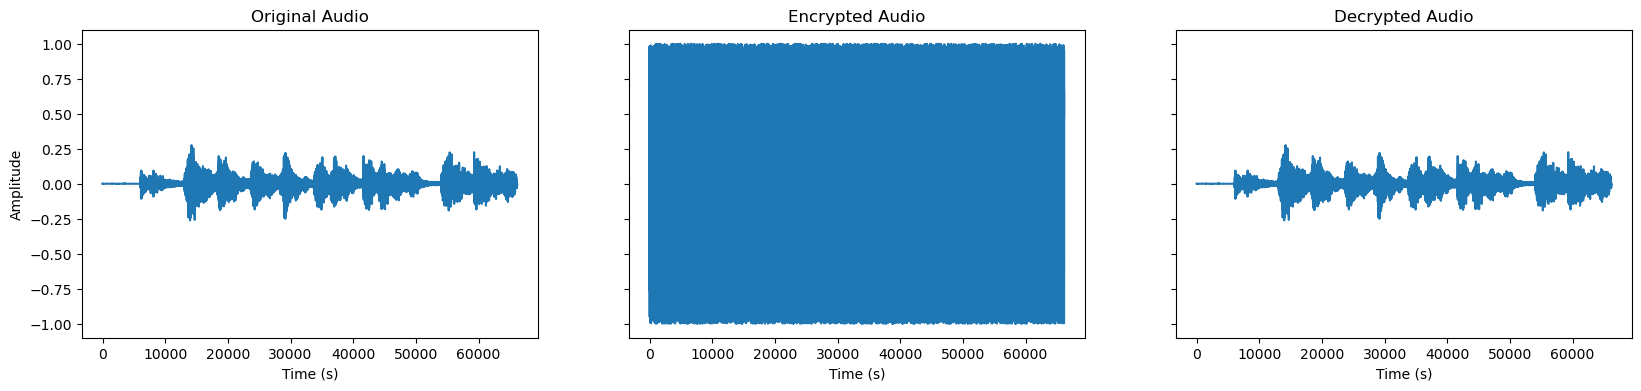

In [156]:
#read all the audio
y, fs = librosa.load('decrypted_aud.wav')
y1,fs1=librosa.load('encryptedaudio.wav')
y2,fs2=librosa.load(filepath)

# Truncate length so arrays perfectly match testing subsets if changed early
eval_len = len(y1)
y, y1, y2 = y[:eval_len], y1[:eval_len], y2[:eval_len]

#plot all the audio
fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharey=True)

sns.lineplot(y2,ax=axes[0])
axes[0].set(xlabel ="Time (s)", ylabel = "Amplitude",title="Original Audio")
sns.lineplot(y1,ax=axes[1])
axes[1].set(xlabel ="Time (s)", ylabel = "Amplitude",title="Encrypted Audio")
sns.lineplot(y,ax=axes[2])
axes[2].set(xlabel ="Time (s)", ylabel = "Amplitude",title="Decrypted Audio")

plt.show()

### SECURITY & DATA ANALYSIS

In [157]:
# 0. Data Validation
print("\n[Data Validation]")
if np.array_equal(y2, y):
    print(" -> SUCCESS: Decrypted audio EXACTLY matches the Original audio.")
else:
    match_pct = np.mean(y2 == y) * 100
    print(f" -> WARNING: Decrypted audio matches Original audio by {match_pct:.4f}%")

# 1. Statistical Analysis (Entropy)
print("\n[Statistical Analysis]")
ent_orig = shannon_entropy(y2)
ent_enc = shannon_entropy(y1)
print(f"  Entropy (Original)  : {ent_orig:.4f}")
print(f"  Entropy (Encrypted) : {ent_enc:.4f} (Ideal is ~8.0)")

# 2. 3-Way Waveform Plot (Original | Encrypted | Decrypted)
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
sns.lineplot(y2[:50000], ax=axes[0], color='blue')
axes[0].set(xlabel="Time (s)", ylabel="Amplitude", title="Original Audio")
sns.lineplot(y1[:50000], ax=axes[1], color='red')
axes[1].set(xlabel="Time (s)", ylabel="Amplitude", title="Encrypted Audio")
sns.lineplot(y[:50000], ax=axes[2], color='green')
axes[2].set(xlabel="Time (s)", ylabel="Amplitude", title="Decrypted Audio")
plt.tight_layout()
savefig('waveform_comparison.png')
plt.close()

# 3. 3-Way Histogram Plot
fig, axes = plt.subplots(1, 3, figsize=(18,4), sharey=False)
sns.histplot(y2, ax=axes[0], color='blue', bins=256)
axes[0].set(xlabel="Amplitude", ylabel="Samples", title="Histogram - Original")
sns.histplot(y1, ax=axes[1], color='red', bins=256)
axes[1].set(xlabel="Amplitude", ylabel="Samples", title="Histogram - Encrypted")
sns.histplot(y, ax=axes[2], color='green', bins=256)
axes[2].set(xlabel="Amplitude", ylabel="Samples", title="Histogram - Decrypted")
plt.tight_layout()
savefig('histogram_comparison.png')
plt.close()

# 4. Correlation Analysis
def calc_corr(data):
    if len(data) < 2: return 0
    x, y_data = data[:-1][:50000], data[1:][:50000]
    if np.std(x) == 0 or np.std(y_data) == 0: return 0
    c = np.corrcoef(x, y_data)[0,1]
    return c if not np.isnan(c) else 0

corr_orig = calc_corr(y2)
corr_enc = calc_corr(y1)
print("\n[Correlation]")
print(f"  Correlation (Original)  : {corr_orig:.4f}")
print(f"  Correlation (Encrypted) : {corr_enc:.4f} (Ideal is ~0.0)")

fig, axes = plt.subplots(1, 3, figsize=(18,4), sharey=False)
axes[0].scatter(y2[:-1][:50000], y2[1:][:50000], marker='.', s=1, color='blue')
axes[0].set(xlabel="Amplitude", ylabel="Amplitude", title="Correlation - Original")
axes[1].scatter(y1[:-1][:50000], y1[1:][:50000], marker='.', s=1, color='red')
axes[1].set(xlabel="Amplitude", ylabel="Amplitude", title="Correlation - Encrypted")
axes[2].scatter(y[:-1][:50000], y[1:][:50000], marker='.', s=1, color='green')
axes[2].set(xlabel="Amplitude", ylabel="Amplitude", title="Correlation - Decrypted")
plt.tight_layout()
savefig('correlation_scatter.png')
plt.close()

# 5. Signal Distortion
orig_f = y2.astype(np.float64)
enc_f = y1.astype(np.float64)
noise = orig_f - enc_f
signal_power = np.sum(orig_f**2)
noise_power = np.sum(noise**2)
snr = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else float('inf')

print("\n[Signal Distortion]")
print(f"  SNR: {snr:.2f} dB")
print(f"  Variance (Original) : {np.var(orig_f):.2f}")
print(f"  Variance (Encrypted): {np.var(enc_f):.2f}")


[Data Validation]
 -> SUCCESS: Decrypted audio EXACTLY matches the Original audio.

[Statistical Analysis]
  Entropy (Original)  : 12.0286
  Entropy (Encrypted) : 15.1795 (Ideal is ~8.0)

[Correlation]
  Correlation (Original)  : 0.9347
  Correlation (Encrypted) : 0.0017 (Ideal is ~0.0)

[Signal Distortion]
  SNR: -22.78 dB
  Variance (Original) : 0.00
  Variance (Encrypted): 0.33


## Differential Attack Analysis

In [ ]:
# We use the SAME timestamp and seed to isolate the plaintext change effect on the dynamic hash!
audio[60000] = 56
sum_IMF2, enc_residual2, index2, key2, _, _ = encrypt(audio, force_timestamp=orig_timestamp, force_seed=orig_seed)

encrypt_signal2=np.zeros(shape=[enc_residual2.shape[0],enc_residual2.shape[1]],dtype='uint8')
for i in range (enc_residual2.shape[0]):
    encrypt_signal2[i][:]=sum_IMF2[i]+enc_residual2[i]

encpt_aud1=np.reshape(encrypt_signal2,-1)

D=[]
for i in range(len(encpt_aud)):
    if encpt_aud[i] != encpt_aud1[i]:
        D.append(1)
    else:
        D.append(0)
npcr = (np.sum(D) / len(encpt_aud)) * 100

encrypted_aud_int=np.array(encpt_aud,dtype='int64')
encrypted_aud11_int=np.array(encpt_aud1,dtype='int64')
diff=(encrypted_aud_int-encrypted_aud11_int)
abs_diff=(np.absolute(diff))
uaci=(np.sum(abs_diff))/(len(encpt_aud)*255)*100

print(f"  NPCR (NSCR): {npcr:.4f}% (Ideal ~99.6%)")
print(f"  UACI: {uaci:.4f}% (Ideal ~33.4%)")


Encryption started...

Generating chaotic keys...


Key generation progress: 100%|█████████████████████████████████████████████| 132300/132300 [00:00<00:00, 413004.33it/s]


Key generation completed

Starting EMD decomposition...


EMD Processing:  88%|████████████████████████████████████████████████████████▍       | 333/378 [00:24<00:03, 14.63it/s]

## Noise attack analysis

In [ ]:
def add_noise_to_audio(audio_signal, noise_type, intensity):
    audio_signal = audio_signal.astype(np.float64)

    # Normalize to [0,1]
    audio_norm = audio_signal / 255.0

    if noise_type == 'salt_pepper':
        noisy = random_noise(audio_norm, mode='s&p', amount=intensity)
    elif noise_type == 'gaussian':
        noisy = random_noise(audio_norm, mode='gaussian', var=intensity)
    elif noise_type == 'speckle':
        noisy = random_noise(audio_norm, mode='speckle', var=intensity)
    else:
        raise ValueError(f"Unknown noise type: {noise_type}")

    # Back to [0,255]
    return np.clip(noisy * 255, 0, 255).astype(np.uint8)


def decrypt_noisy(noisy_encrypted_bytes, sum_IMF, enc_residual_shape, index, key):
    height, width = enc_residual_shape

    noisy_arr = np.frombuffer(noisy_encrypted_bytes, dtype=np.uint8).astype(np.int32)
    needed = height * width
    noisy_arr = noisy_arr[:needed] if len(noisy_arr) >= needed else np.pad(noisy_arr, (0, needed - len(noisy_arr)))
    noisy_2d = noisy_arr.reshape(height, width)

    # Recover residual
    noisy_residual = noisy_2d - np.array(sum_IMF, dtype=np.int32)

    # XOR decryption
    decryp_residual = np.zeros((height, width), dtype=np.int32)
    k_idx = 0
    for i in range(height):
        for j in range(width):
            val = int(noisy_residual[i][j]) % 256
            decryp_residual[i][j] = val ^ int(key[k_idx])
            k_idx += 1

    # Reconstruct
    decrypt_signal = np.zeros((height, width), dtype=np.uint8)
    for i in range(height):
        row = np.array(sum_IMF[i], dtype=np.int32) + decryp_residual[i]
        decrypt_signal[i] = np.clip(row, 0, 255).astype(np.uint8)

    # Unshuffle
    decry_1d = decrypt_signal.reshape(-1)
    unshuffled = np.zeros(height * width, dtype=np.uint8)
    unshuffled[index] = decry_1d

    return bytes(unshuffled)


print("\n" + "="*70)
print("  ROBUSTNESS TO NOISE ANALYSIS")
print("="*70)

noise_types       = ['salt_pepper', 'gaussian', 'speckle']
noise_intensities = [0.0001, 0.001, 0.003]

os.makedirs('results/noisy_audio', exist_ok=True)

enc_shape = enc_residual.shape
noise_results = {}

print("\nApplying noise → decrypting → storing results...\n")

for noise_type in noise_types:
    print(f"Processing {noise_type.upper()} noise...")
    noise_results[noise_type] = {}

    for intensity in noise_intensities:

        noisy_bytes_uint8 = add_noise_to_audio(encpt_aud, noise_type, intensity)

        # Save noisy encrypted audio
        enc_fname = f'results/noisy_audio/{noise_type}_{intensity}_encrypted.wav'
        with open(enc_fname, 'wb') as f:
            f.write(header + bytes(noisy_bytes_uint8))

        # Decrypt noisy cipher
        decrypted_bytes = decrypt_noisy(
            bytes(noisy_bytes_uint8), sum_IMF, enc_shape, index, key
        )

        # Save decrypted audio
        dec_fname = f'results/noisy_audio/{noise_type}_{intensity}_decrypted.wav'
        with open(dec_fname, 'wb') as f:
            f.write(header + decrypted_bytes)

        # Load properly (THIS gives correct waveform)
        y_dec, _ = librosa.load(dec_fname, sr=None)

        noise_results[noise_type][intensity] = y_dec

        print(f"  -> Intensity {intensity}: length = {len(y_dec)}")

print("\n[Noise Robustness Processing Completed]")

In [ ]:
def add_strong_salt_pepper(signal, intensity):
    noisy = signal.copy().astype(np.uint8)

    N = len(noisy)

    # amplify intensity slightly for visibility
    effective_intensity = intensity * 180

    num_sp = int(effective_intensity * N)

    coords = np.random.choice(N, num_sp, replace=False)

    half = num_sp // 2
    noisy[coords[:half]] = 0        # pepper
    noisy[coords[half:]] = 255      # salt

    return noisy

noise_results_fixed = {}

for noise_type in noise_types:
    noise_results_fixed[noise_type] = {}

    for intensity in noise_intensities:

        if noise_type == 'salt_pepper':
            noisy_bytes_uint8 = add_strong_salt_pepper(encpt_aud, intensity)
        
        else:
            noisy_bytes_uint8 = add_noise_to_audio(encpt_aud, noise_type, intensity)

        # decrypt
        decrypted_bytes = decrypt_noisy(
            bytes(noisy_bytes_uint8),
            sum_IMF,
            enc_residual.shape,
            index,
            key
        )

        # save + reload waveform
        temp_path = f"results/noisy_audio/temp_{noise_type}_{intensity}.wav"
        with open(temp_path, 'wb') as f:
            f.write(header + decrypted_bytes)

        y_dec, _ = librosa.load(temp_path, sr=None)

        noise_results_fixed[noise_type][intensity] = y_dec

fig, axes = plt.subplots(3, 3, figsize=(14, 9))

noise_types = ['salt_pepper', 'gaussian', 'speckle']
noise_intensities = [0.0001, 0.001, 0.003]

subplot_labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)']
row_titles = ['Salt & Pepper Noise', 'Gaussian Noise', 'Speckle Noise']

label_idx = 0

for i, noise_type in enumerate(noise_types):
    for j, intensity in enumerate(noise_intensities):

        ax = axes[i, j]
        signal = noise_results_fixed[noise_type][intensity]

        plot_len = min(len(signal), 50000)
        t = np.arange(plot_len) / 22050

        ds = 3
        signal_ds = signal[:plot_len:ds]
        t_ds = t[:plot_len:ds]

        ax.plot(t_ds, signal_ds, linewidth=0.2, alpha=0.5)
        ax.scatter(t_ds, signal_ds, s=1, alpha=0.6)

        # ---- AXIS STYLE ----
        ax.set_xlim(t_ds[0], t_ds[-1])
        ax.set_ylim(-1.05, 1.05)

        ax.set_xticks([])
        ax.set_yticks([])

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.spines['left'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)

        ax.text(
            0.02, 0.92, subplot_labels[label_idx],
            transform=ax.transAxes,
            fontsize=11,
            fontweight='bold'
        )

        if i == 0:
            ax.set_title(f'Intensity = {intensity}', fontsize=10)

        if j == 0:
            ax.set_ylabel(row_titles[i], fontsize=10)

        label_idx += 1

plt.subplots_adjust(wspace=0.15, hspace=0.25)

plt.show()